<a href="https://colab.research.google.com/github/Ahanti05/Heatmap/blob/main/Minipro_Heatmap_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project Overview

##Goal-




Show how active different regions in a surveillance area are by creating a heatmap of movement activity.

##Concepts used-

Motion detection, data aggregation, visualization.

#Code

##Initial installation of libraries-

In [ ]:
#Installing the required libraies

%%capture
!pip install opencv-python numpy matplotlib seaborn


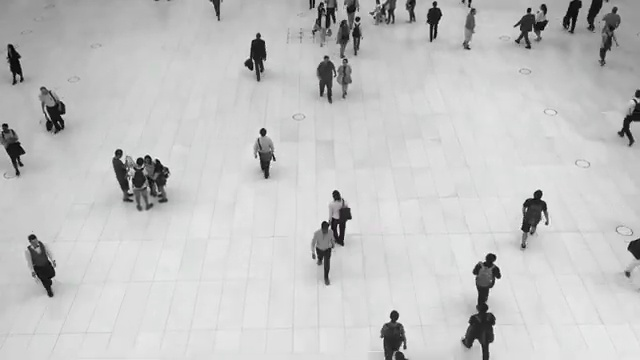

In [ ]:
#Uploading a video from local system
from google.colab import files
uploaded = files.upload()

# Importing libraries
import cv2
import time
from IPython.display import display, clear_output, Image


#Create Background Subtractor: to diffrenciate static(background) from moving(foreground)
fgbg = cv2.createBackgroundSubtractorMOG2()


# OpenCV treats video as a sequence of frames
# Make sure the filename here matches the one uploaded above (use os.listdir() if unsure)
cap = cv2.VideoCapture('minipro_finalvideo.mp4')

# Loop through each frame
while True:
    ret, frame = cap.read()  # cap.read() → (success_flag, frame_array)
    if not ret:              # Stops when video ends or frame not read
        break

    # Convert BGR (OpenCV format) → RGB (Colab display format)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Apply background subtractor — this detects motion
    fgmask = fgbg.apply(frame)


    # Display frame in notebook (simulate video playback)
    clear_output(wait=True)  # Clears previous frame from cell output
    display(Image(data=cv2.imencode('.jpg', frame)[1]))  # Display current frame
    time.sleep(0.03)  # Pause ≈30fps (smooth playback speed)

# Release video object
cap.release()






In [ ]:
import os
os.listdir()  #for checking the exact filename inside the directory


['.config',
 'minipro_finalvideo (1).mp4',
 'minipro_finalvideo.mp4',
 'sample_data']

In [ ]:
import numpy as np

# Read one frame to get the video’s dimensions
cap = cv2.VideoCapture('minipro_finalvideo.mp4')
ret, frame = cap.read()     #--------reads one frame to extract dimensions

if not ret:
    print("Could not read the video. Check the filename or upload again.")
else:
    # Get frame height and width
    height, width = frame.shape[:2]     #--------gets image height and width

    # Define grid size (10×10 zones)
    grid_size = 10     #--------divides frame into 10x10 regions

    # Create a 10×10 matrix initialized with zeros — each cell stores motion activity count
    activity = np.zeros((grid_size, grid_size), dtype=int)      #-------initializes motion counters (all start at zero)

    # Calculate height and width of each zone
    zone_h = height // grid_size    #------size of each cell in pixels
    zone_w = width // grid_size

    print(f"✅ Frame size: {width}×{height}")       #---------all print lines: confirms if everything is correctly set up
    print(f"✅ Each grid cell: {zone_w}×{zone_h} pixels")
    print("✅ Activity grid created with shape:", activity.shape)



✅ Frame size: 640×360
✅ Each grid cell: 64×36 pixels
✅ Activity grid created with shape: (10, 10)


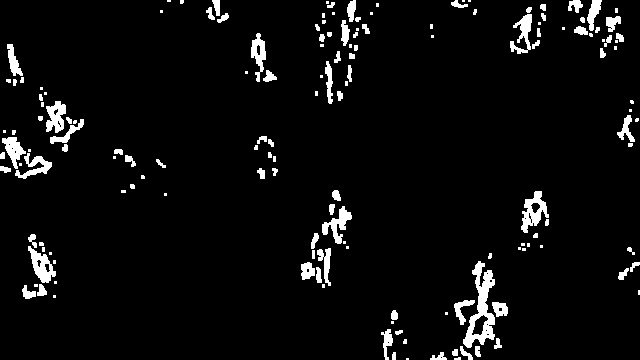

Motion detection complete with adaptive threshold + contours!
Updated Activity Matrix:
 [[ 0  0  0  0  0  0  0  0  0  0]
 [ 1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  1  5  0 19  0]
 [ 0  0  0  0  3  3 27  0  0  2]
 [ 8  0  3  0  1  0 28  0 18  1]
 [35  0 32  0  0  0 18 11 21  0]
 [14  0 65 31  0  1 24 36 18  4]
 [12  0 43 20  1  4 49 49  4 19]
 [ 0  0  0  0  0  0  9  7  1  0]]


In [ ]:
#Reopen the same video file
cap = cv2.VideoCapture('minipro_finalvideo.mp4')

#Calculate zone (cell) height and width for 10×10 grid
zone_h = height // grid_size
zone_w = width // grid_size

#Reset video position to the beginning
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

#Loop through video frames
while True:
    ret, frame = cap.read()
    if not ret:
        break  # End of video

    # Convert to grayscale for easier motion detection
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Apply your MOG2 background subtractor
    fgmask = fgbg.apply(gray)

    # Adaptive Thresholding (replaces static 200+ threshold)
    adaptive = cv2.adaptiveThreshold(
        fgmask,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        15,
        -2
    )

    # Noise removal
    kernel = np.ones((3,3), np.uint8)
    clean = cv2.morphologyEx(adaptive, cv2.MORPH_OPEN, kernel)

    # Contour detection for accurate motion shapes
    contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Update your activity grid using contours
    for cnt in contours:
        if cv2.contourArea(cnt) < 500:
            continue  # skip tiny noise

        x, y, w, h = cv2.boundingRect(cnt)

        # Find grid cell location based on contour position
        zone_i = min(y // zone_h, grid_size - 1)
        zone_j = min(x // zone_w, grid_size - 1)

        activity[zone_i, zone_j] += 1

    # Display motion mask (contour-based)
    mask_vis = cv2.cvtColor(clean, cv2.COLOR_GRAY2RGB)
    clear_output(wait=True)
    display(Image(data=cv2.imencode('.jpg', mask_vis)[1]))
    time.sleep(0.03)

cap.release()

print("Motion detection complete with adaptive threshold + contours!")
print("Updated Activity Matrix:\n", activity)



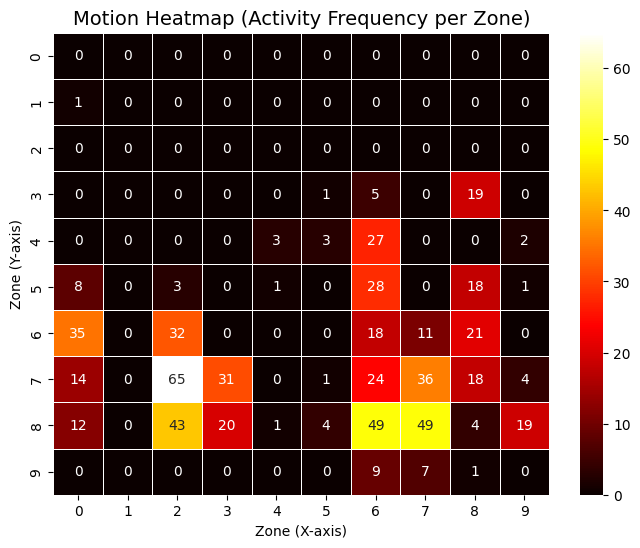

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display the heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(activity, cmap='hot', linewidths=0.5, annot=True, fmt='d')

plt.title("Motion Heatmap (Activity Frequency per Zone)", fontsize=14)
plt.xlabel("Zone (X-axis)")
plt.ylabel("Zone (Y-axis)")
plt.show()


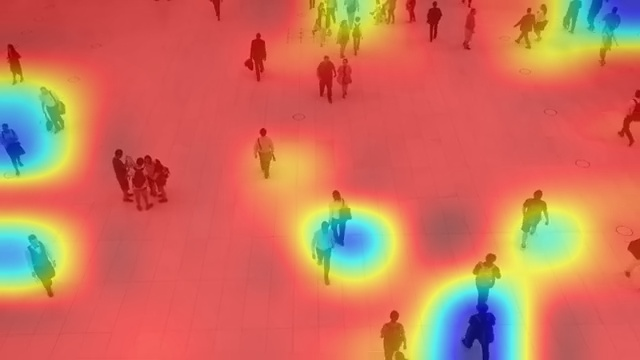

In [ ]:
import cv2
import numpy as np
import time
from IPython.display import display, clear_output, Image

# --- Load video ---
cap = cv2.VideoCapture('minipro_finalvideo.mp4')

# Background subtractor (motion detector)
fgbg = cv2.createBackgroundSubtractorMOG2(history=300, varThreshold=25, detectShadows=False)

# Read first frame to get video size
ret, frame = cap.read()
height, width = frame.shape[:2]

# Grid size
grid_size = 10
zone_h = height // grid_size
zone_w = width // grid_size

# Activity matrix (starts with all zeros)
activity = np.zeros((grid_size, grid_size), dtype=np.float32)

print("Dynamic Live Heatmap Running...")

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # ------- 1. Get motion mask -------
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    fgmask = fgbg.apply(gray)

    # Remove noise → binary motion mask
    fgmask = cv2.GaussianBlur(fgmask, (7,7), 0)
    _, fgmask = cv2.threshold(fgmask, 180, 255, cv2.THRESH_BINARY)

    # ------- 2. Update activity live (per-cell) -------
    for i in range(grid_size):
        for j in range(grid_size):
            y1, y2 = i * zone_h, (i + 1) * zone_h
            x1, x2 = j * zone_w, (j + 1) * zone_w
            zone = fgmask[y1:y2, x1:x2]

            motion = np.sum(zone == 255)

            # Live update: decay + add
            activity[i, j] *= 0.95         # slowly fade old heat (decay)
            if motion > 200:
                activity[i, j] += motion / 5000.0  # normalize motion intensity

    # ------- 3. Convert activity → heatmap -------
    heatmap_resized = cv2.resize(activity, (width, height), interpolation=cv2.INTER_CUBIC)
    heatmap_resized = cv2.GaussianBlur(heatmap_resized, (51, 51), 0)

    heatmap_norm = cv2.normalize(heatmap_resized, None, 0, 255, cv2.NORM_MINMAX)
    heatmap_color = cv2.applyColorMap(heatmap_norm.astype(np.uint8), cv2.COLORMAP_JET)

    # ------- 4. Blend heatmap with original frame -------
    overlay = cv2.addWeighted(heatmap_color, 0.6, frame, 0.4, 0)

    # ------- 5. Display in Colab -------
    overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    clear_output(wait=True)
    display(Image(data=cv2.imencode('.jpg', overlay_rgb)[1]))

    time.sleep(0.03)  # ~30FPS

cap.release()

